# Experiment 4: EfficientNet

In [ ]:
import tensorflow as tf
import numpy as np
import cv2

In [2]:
def load_image(image_path):
    """
    Load preprocessed image.
    
    """

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise Exception(f"Could not load image: {image_path}")

    # Convert to float32
    image = image.astype(np.float32)

    # Add grayscale channel to expand dimensions to 244x244x3
    image = np.expand_dims(image, axis=-1)

    # Convert grayscale to RGB
    image = np.repeat(image, 3, axis=-1)

    return image

In [3]:
def create_dataset(image_paths, labels, batch_size=32, shuffle=True):
    images = []

    for path in image_paths:
        image = load_image(path)
        images.append(image)

    images = np.array(images)
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [4]:
import src.ImagesPreprocessorService

In [5]:
( complete_dataset, training_dataset, validation_dataset, testing_dataset) = src.ImagesPreprocessorService.load_processed_dataset()
(X_train, y_train, X_val, y_val, X_test, y_test) = src.ImagesPreprocessorService.get_labeled_datasets(training_dataset, validation_dataset, testing_dataset)

In [6]:
train = create_dataset( X_train, y_train)
val = create_dataset( X_val, y_val, shuffle=False)
test = create_dataset(X_test, y_test, shuffle=False)

In [7]:
from src.models import EfficientNetBinaryClassifier

In [8]:
effNetModel = EfficientNetBinaryClassifier(train_backbone=False, dropout_rate=0.0)

effNetModel.build((None, 224, 224, 3))

effNetModel.summary()

Model: "efficient_net_binary_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  multiple                 0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           multiple                  0         
                                                                 
 dense (Dense)               multiple                  163968    
                                                                 
 batch_normalization (BatchN  multiple                 512       
 ormalization)                                                   
                                                                 
 dense_1 (Dense)             multip

In [9]:
effNetModel.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [10]:
# Create callbacks
CHECKPOINT_DIR = Path(".") / "checkpoints" / "EfficientNet"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_DIR / "efficientnet_epoch-{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_best_only=False, # Save weights for every epoch
    monitor="val_loss",
    mode="min",
    verbose=1
)

class_weight = {
    0: 2.8,   # NORMAL
    1: 1.0    # PNEUMONIA
}

history = effNetModel.fit(train, validation_data=val, epochs=10, class_weight=class_weight, callbacks=[checkpoint_callback])

Epoch 1/10
148/148 [==============================] - 25s 102ms/step - loss: 0.4878 - accuracy: 0.8173 - precision: 0.9793 - recall: 0.7702 - val_loss: 0.3706 - val_accuracy: 0.9027 - val_precision: 0.9971 - val_recall: 0.8715
Epoch 2/10
148/148 [==============================] - 12s 79ms/step - loss: 0.2876 - accuracy: 0.9074 - precision: 0.9935 - recall: 0.8809 - val_loss: 0.2089 - val_accuracy: 0.9408 - val_precision: 0.9918 - val_recall: 0.9280
Epoch 3/10
148/148 [==============================] - 12s 79ms/step - loss: 0.2254 - accuracy: 0.9390 - precision: 0.9932 - recall: 0.9242 - val_loss: 0.1462 - val_accuracy: 0.9580 - val_precision: 0.9893 - val_recall: 0.9537
Epoch 4/10
148/148 [==============================] - 12s 79ms/step - loss: 0.1987 - accuracy: 0.9444 - precision: 0.9927 - recall: 0.9319 - val_loss: 0.1633 - val_accuracy: 0.9504 - val_precision: 0.9946 - val_recall: 0.9383
Epoch 5/10
148/148 [==============================] - 12s 79ms/step - loss: 0.1650 - accuracy: 

In [11]:
results = effNetModel.evaluate(test)

print(results)

20/20 [==============================] - 2s 73ms/step - loss: 0.3701 - accuracy: 0.8654 - precision: 0.8283 - recall: 0.9897
[0.3700686991214752, 0.8653846383094788, 0.8283261656761169, 0.9897436499595642]


In [12]:
#effNetModel.backbone.summary()

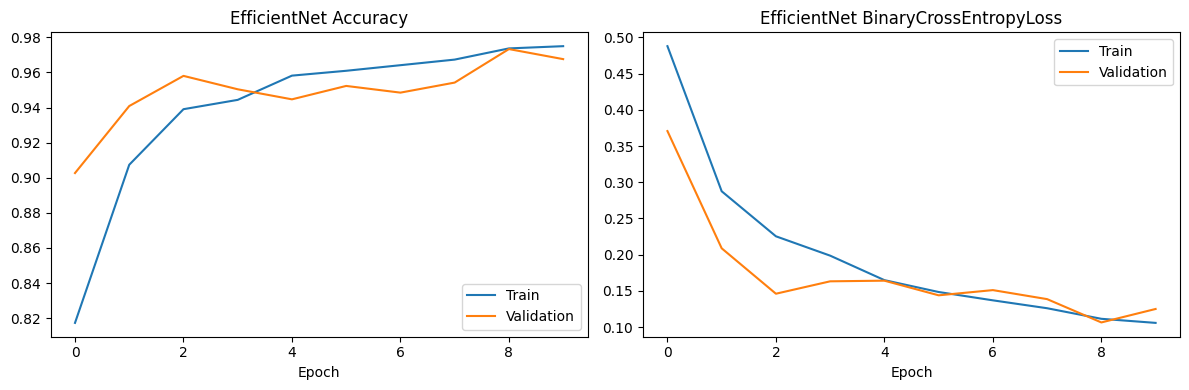

In [13]:
from pathlib import Path
from src.plot import plot_history

FIG_DIR = Path(".") / "outputs" / "EfficientNet"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "EfficientNet"

plot_history(history, MODEL_NAME, FIG_DIR / "training_history.png")

## Evaluation

Run `Evaluation.ipynb`.